# Projekt: Zaawansowana Analiza i Predykcja Rotacji Pracowników (Employee Attrition)
## Część Analityczna

---

### 1. Wybór i uzasadnienie zestawu danych

* **Zestaw danych:** IBM HR Analytics Employee Attrition & Performance (`WA_Fn-UseC_-HR-Employee-Attrition.csv`).
* **Adekwatność do problemu biznesowego:** Zbiór zawiera szczegółowe dane o 3000 pracownikach opisane za pomocą 35 cech. Obejmują one profil demograficzny, satysfakcję ze środowiska pracy, poziom wynagrodzeń, historię zatrudnienia oraz kluczową zmienną docelową – informację o odejściu z firmy (`Attrition`). Jest to klasyczne, a zarazem krytyczne zagadnienie z obszaru *People Analytics / HR Tech*, ukierunkowane na identyfikację predyktorów ryzyka odejścia pracowników i minimalizację kosztów rekrutacji oraz retencji talentów.
* **Zastosowanie metod sztucznej inteligencji (AI):** 1. **Uczenie nadzorowane:** Problem redukuje się do klasyfikacji binarnej, gdzie model uczy się przewidywać wartość zmiennej docelowej `Attrition` (`Yes` / `No`).
    2. **Porównanie algorytmów:** Dane pozwalają na wdrożenie i walidację szerokiego spektrum klasyfikatorów – od modeli liniowych po zaawansowane algorytmy zespołowe.
    3. **Wyjaśnialność modeli (XAI):** Struktura zbioru umożliwia przeprowadzenie analizy ważności cech (*Feature Importance*), co ma fundamentalne znaczenie dla podejmowania strategicznych decyzji zarządczych.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, f1_score, precision_recall_curve
)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[INFO] XGBoost niedostępny – zastąpiony GradientBoostingClassifier")

import warnings
warnings.filterwarnings('ignore')

url = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
print(f"Pomyślnie załadowano zbiór danych. Kształt macierzy: {df.shape}")


Pomyślnie załadowano zbiór danych. Kształt macierzy: (3000, 35)


### 2. Analiza eksploracyjna zbioru danych (EDA)

W ramach wstępnego etapu analizy danych (Exploratory Data Analysis) przeprowadzimy audyt struktury technicznej zbioru, dokonamy ewaluacji rozkładów statystycznych, zidentyfikujemy anomalie (w tym kolumny bezwartościowe informacyjnie) oraz zbadamy korelacje między cechami a skłonnością do rotacji.

#### 2.1 Struktura techniczna danych oraz typy zmiennych
W pierwszej kolejności weryfikujemy kształt macierzy danych, nazewnictwo kolumn oraz przypisane im typy danych (numeryczne `int64` oraz kategoryczne/tekstowe `object` lub `str`).

In [19]:
print("--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---")
df.info()

--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       3000 non-null   int64
 1   Attrition                 3000 non-null   str  
 2   BusinessTravel            3000 non-null   str  
 3   DailyRate                 3000 non-null   int64
 4   Department                3000 non-null   str  
 5   DistanceFromHome          3000 non-null   int64
 6   Education                 3000 non-null   int64
 7   EducationField            3000 non-null   str  
 8   EmployeeCount             3000 non-null   int64
 9   EmployeeNumber            3000 non-null   int64
 10  EnvironmentSatisfaction   3000 non-null   int64
 11  Gender                    3000 non-null   str  
 12  HourlyRate                3000 non-null   int64
 13  JobInvolvement            3000 non-null   int64
 14  JobLe

#### 2.2 Weryfikacja kompletności danych (Missing Values Audit)
Przed przystąpieniem do modelowania matematycznego konieczne jest sprawdzenie występowania braków w danych (`NaN` / `Null`). Brakujące wartości mogłyby zaburzyć proces uczenia algorytmów lub wymagać zastosowania metod imputacji (np. średnią, medianą lub modelem KNN).Sprawdzenie braków w danych bezpośrednio

In [20]:
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Całkowita liczba brakujących wartości w zbiorze: {total_missing}")
if total_missing > 0:
    print(missing_values[missing_values > 0])

Całkowita liczba brakujących wartości w zbiorze: 0


#### 2.3 Opis statystyczny cech numerycznych
Generujemy podstawowe miary tendencji centralnej oraz dyspersji (średnia, odchylenie standardowe, kwartyle, wartości ekstremalne) dla cech ilościowych. Pozwala to na wstępne wykrycie potencjalnych wartości odstających (*outliers*) oraz ocenę skali i zakresów zmiennych, co jest kluczowe dla modeli wrażliwych na rozpiętość cech.

In [21]:
print("--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---")
display(df.describe().T)

--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---


,count,mean,std,min,25%,50%,75%,max
Age,3000.0,36.884667,9.310080,18.0,30.00,35.0,43.00,60.0
DailyRate,3000.0,794.002000,406.103612,102.0,448.00,792.5,1150.25,1499.0
DistanceFromHome,3000.0,9.300333,8.158165,1.0,2.00,7.0,14.00,29.0
Education,3000.0,2.932667,1.051587,1.0,2.00,3.0,4.00,5.0
EmployeeCount,3000.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,3000.0,1500.500000,866.169729,1.0,750.75,1500.5,2250.25,3000.0
EnvironmentSatisfaction,3000.0,2.714333,1.099605,1.0,2.00,3.0,4.00,4.0
HourlyRate,3000.0,66.660333,20.425557,30.0,49.00,67.0,84.25,100.0
JobInvolvement,3000.0,2.735000,0.715737,1.0,2.00,3.0,3.00,4.0
JobLevel,3000.0,2.069000,1.131665,1.0,1.00,2.0,3.00,5.0


#### 2.4 Identyfikacja i eliminacja cech stałych (Zero-Variance Features)
Cechy, które przyjmują dokładnie jedną, stałą wartość dla każdego rekordu w bazie danych, posiadają zerową wariancję. Z punktu widzenia uczenia maszynowego nie wnoszą one żadnej wartości predykcyjnej (nie różnicują próbek), a zwiększają wymiarowość zbioru. Należy je zidentyfikować w celu późniejszego usunięcia w potoku przetwarzania.

In [23]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Zidentyfikowane cechy stałe (zerowa wariancja): {constant_cols}")

Zidentyfikowane cechy stałe (zerowa wariancja): ['EmployeeCount', 'Over18', 'StandardHours']


#### 2.5 Analiza korelacji liniowej zmiennych ze zmienną docelową
Aby zbadać liniową zależność zmiennych numerycznych ze skłonnością do odejścia, transformujemy zmienną docelową `Attrition` oraz kluczową zmienną kategoryczną `OverTime` na postać binarną (0/1). Następnie wyznaczamy współczynniki korelacji Pearsona, co pozwoli wyłonić najsilniejsze, potencjalne predyktory rotacji.

In [24]:
df_numeric_analysis = df.copy()
df_numeric_analysis['Attrition_numeric'] = df_numeric_analysis['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_numeric_analysis['OverTime_numeric'] = df_numeric_analysis['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_cols = df_numeric_analysis.select_dtypes(include=[np.number]).columns
correlations = df_numeric_analysis[numeric_cols].corr()['Attrition_numeric'].sort_values(ascending=False)

print("--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---")
print(correlations)

--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---
Attrition_numeric           1.000000
OverTime_numeric            0.238545
DistanceFromHome            0.075815
NumCompaniesWorked          0.068779
MonthlyRate                 0.030601
PercentSalaryHike           0.015545
PerformanceRating           0.015137
EmployeeNumber             -0.008192
HourlyRate                 -0.018491
Education                  -0.019217
DailyRate                  -0.027544
RelationshipSatisfaction   -0.049283
YearsSinceLastPromotion    -0.063834
EnvironmentSatisfaction    -0.071784
WorkLifeBalance            -0.072502
TrainingTimesLastYear      -0.081699
JobSatisfaction            -0.110913
JobInvolvement             -0.126911
StockOptionLevel           -0.148116
YearsAtCompany             -0.148492
YearsWithCurrManager       -0.163327
Age                        -0.173150
YearsInCurrentRole         -0.175921
JobLevel                   -0.185654
MonthlyIncome              -0.186083
TotalWorkingYea

#### 2.6 Zaawansowana wizualizacja i interpretacja dystrybucji danych

Kluczowym elementem EDA jest graficzne przedstawienie zachowań danych. Przeprowadzimy wizualizację dwóch podstawowych obszarów:
1. **Rozkład zmiennej docelowej (`Attrition`):** Ocena zbalansowania klas w zbiorze. Nierównomierny rozkład (dysproporcja między klasą `No` a `Yes`) zasygnalizuje konieczność użycia odpowiednich metryk (np. F1-score, Recall) zamiast ogólnego Accuracy oraz zastosowania stratyfikacji przy podziale danych.
2. **Macierz korelacji:** Analiza współliniowości (*Multicollinearity*) między cechami, która pozwoli wykryć zmienne silnie ze sobą sprzężone (np. poziom stanowiska a miesięczny dochód).

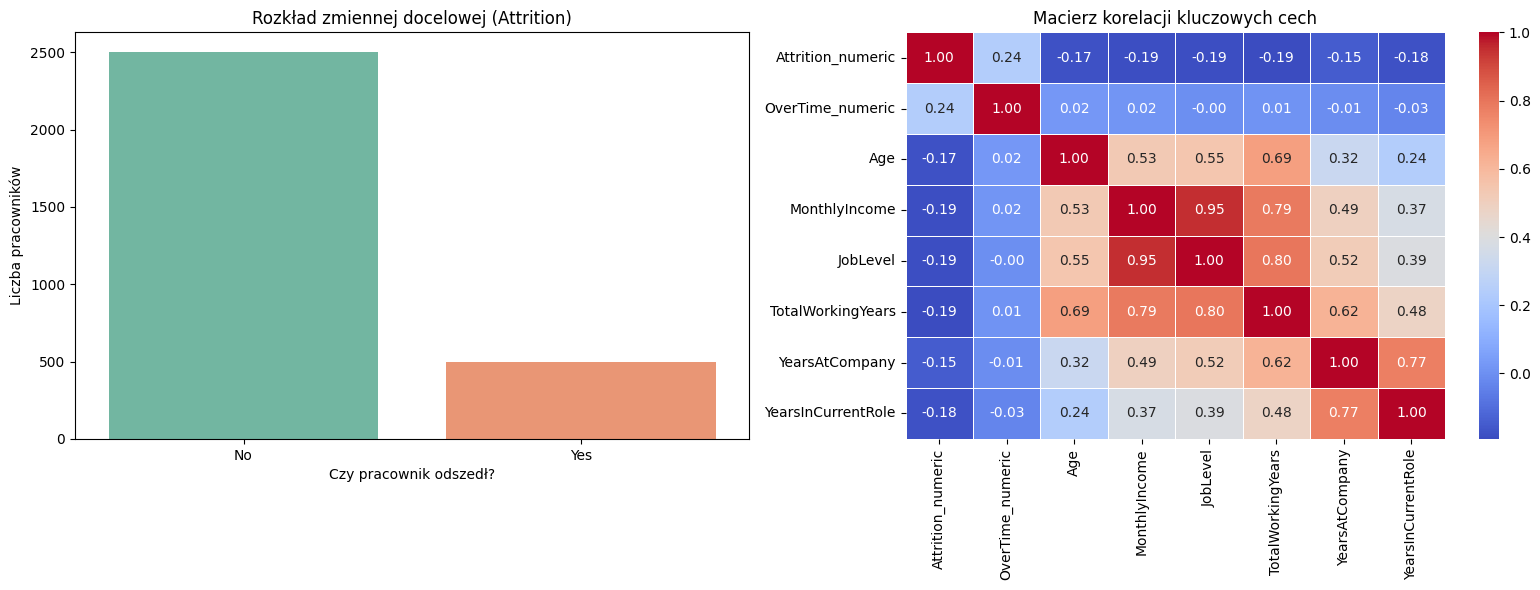

In [25]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Rozkład zmiennej docelowej (Attrition)')
plt.xlabel('Czy pracownik odszedł?')
plt.ylabel('Liczba pracowników')

plt.subplot(1, 2, 2)
selected_features = ['Attrition_numeric', 'OverTime_numeric', 'Age', 'MonthlyIncome', 
                     'JobLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']
corr_sub_matrix = df_numeric_analysis[selected_features].corr()
sns.heatmap(corr_sub_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji kluczowych cech')

plt.tight_layout()
plt.show()

### 3. Sformułowanie hipotezy badawczej

Biorąc pod uwagę wnioski płynące z analizy korelacji – m.in. silny dodatni wpływ pracy w godzinach nadliczbowych (`OverTime`) na rotację oraz ujemny wpływ stabilizacji finansowo-zawodowej (`MonthlyIncome`, `TotalWorkingYears`, `JobLevel`, `Age`) – formułujemy następujące założenia badawcze:

* **Treść hipotezy:** Zastosowanie nieliniowych algorytmów uczenia maszynowego (w szczególności modeli zespołowych opartych na drzewach decyzyjnych) umożliwi predykcję odejść pracowników z ogólną dokładnością (**Accuracy**) na poziomie minimum **85%** oraz czułością (**Recall**) dla klasy pozytywnej (`Attrition` = Yes) wynoszącą co najmniej **70%**.
* **Uzasadnienie biznesowe:** Inżynieria HR wskazuje, że błąd polegający na niesklasyfikowaniu pracownika realnie planującego odejście (*False Negative*) jest znacznie kosztowniejszy niż fałszywy alarm (*False Positive*). Wysoki wskaźnik Recall pozwoli działom HR na podjęcie wcześniejszych działań retencyjnych wobec osób realnie zagrożonych rotacją.
* **Potencjał aplikacyjny:** Model dostarczy nie tylko binarnych etykiet, ale przede wszystkim oszacuje prawdopodobieństwo odejścia każdego pracownika, tworząc operacyjny system wczesnego ostrzegania.

### 4. Badanie aktualnego stanu wiedzy (State-of-the-Art)

Prognozowanie rotacji kadr to jeden z najintensywniej rozwijanych nurtów informatycznych systemów zarządzania zasobami ludzkimi (HRMS).

* **Podejścia tradycyjne:** Przez dekady standardem była statystyczna analiza regresji logistycznej oraz analiza przeżycia (modele hazardów Coxa). Choć cenione za pełną interpretowalność matematyczną, podejścia te charakteryzują się ograniczoną elastycznością – słabo radzą sobie ze złożonymi, nieliniowymi interakcjami cech psychologicznych (np. satysfakcja z pracy) z cechami finansowymi.
* **Nowoczesne rozwiązania AI:** Współczesne badania naukowe udowadniają wyższą skuteczność algorytmów nieparametrycznych i zespołowych, takich jak *Random Forest*, *XGBoost* czy *LightGBM*. Aby zniwelować problem natury "czarnej skrzynki" (*Black Box*), w nowoczesnych systemach powszechnie implementuje się metody wyjaśnialnej sztucznej inteligencji (**XAI**), np. wartości **SHAP** (SHapley Additive exPlanations) lub *Feature Importance*. Pozwala to na precyzyjne wskazanie spersonalizowanych powodów, dla których dany pracownik rozważa opuszczenie organizacji.